# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
from pathlib import Path
import itertools
import string
import operator
import functools

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import numpy as np

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM PORNO
print(' '.join(
    functools.reduce(operator.add, p)
    for p in itertools.product(string.ascii_uppercase, repeat=3)
))

AAA AAB AAC AAD AAE AAF AAG AAH AAI AAJ AAK AAL AAM AAN AAO AAP AAQ AAR AAS AAT AAU AAV AAW AAX AAY AAZ ABA ABB ABC ABD ABE ABF ABG ABH ABI ABJ ABK ABL ABM ABN ABO ABP ABQ ABR ABS ABT ABU ABV ABW ABX ABY ABZ ACA ACB ACC ACD ACE ACF ACG ACH ACI ACJ ACK ACL ACM ACN ACO ACP ACQ ACR ACS ACT ACU ACV ACW ACX ACY ACZ ADA ADB ADC ADD ADE ADF ADG ADH ADI ADJ ADK ADL ADM ADN ADO ADP ADQ ADR ADS ADT ADU ADV ADW ADX ADY ADZ AEA AEB AEC AED AEE AEF AEG AEH AEI AEJ AEK AEL AEM AEN AEO AEP AEQ AER AES AET AEU AEV AEW AEX AEY AEZ AFA AFB AFC AFD AFE AFF AFG AFH AFI AFJ AFK AFL AFM AFN AFO AFP AFQ AFR AFS AFT AFU AFV AFW AFX AFY AFZ AGA AGB AGC AGD AGE AGF AGG AGH AGI AGJ AGK AGL AGM AGN AGO AGP AGQ AGR AGS AGT AGU AGV AGW AGX AGY AGZ AHA AHB AHC AHD AHE AHF AHG AHH AHI AHJ AHK AHL AHM AHN AHO AHP AHQ AHR AHS AHT AHU AHV AHW AHX AHY AHZ AIA AIB AIC AID AIE AIF AIG AIH AII AIJ AIK AIL AIM AIN AIO AIP AIQ AIR AIS AIT AIU AIV AIW AIX AIY AIZ AJA AJB AJC AJD AJE AJF AJG AJH AJI AJJ AJK AJL AJM AJN AJO AJP 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

21

In [4]:
reports_paths.sort_values(ascending=False).head()

16    data/cash_app_report_1783786366452.csv
19    data/cash_app_report_1783720643125.csv
4     data/cash_app_report_1783629391249.csv
10    data/cash_app_report_1783439681167.csv
11    data/cash_app_report_1783357451480.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1783786366452.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-11 10:29:05 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,GME,$21.68,0.461250,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of GameStop,NaN,Cash Balance
1,2026-07-11 07:26:39 EDT,NaN,Bitcoin Sell,USD,$10.00,-$0.20,$9.80,BTC,"$63,645.54",0.000157,COMPLETE,sale of BTC 0.00015712,NaN,Cash Balance
2,2026-07-11 00:09:04 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VONV,$108.27,0.092360,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Vanguard Russell 100...,NaN,Cash Balance
3,2026-07-11 00:08:17 EDT,NaN,Stock Buy,USD,-$20.00,$0.00,-$20.00,C,$140.60,0.142250,WAITING_ON_EXTERNAL,Scheduled $20 Purchase of Citigroup,NaN,Cash Balance
4,2026-07-11 00:06:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$73.37,0.136300,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Netflix,NaN,Cash Balance
5,2026-07-10 17:11:17 EDT,NaN,Deposits,USD,$100.00,$0.00,$100.00,NaN,NaN,NaN,COMPLETE,Add Cash,NaN,Visa debit 3333
6,2026-07-10 17:10:53 EDT,NaN,Stock Buy,USD,-$50.00,$0.00,-$50.00,AMZN,$245.34,0.203800,WAITING_ON_EXTERNAL,Scheduled $50 Purchase of Amazon,NaN,Cash Balance
7,2026-07-10 16:33:55 EDT,NaN,Stock Buy,USD,-$25.00,$0.00,-$25.00,VGLT,$54.06,0.462450,WAITING_ON_EXTERNAL,Scheduled $25 Purchase of Vanguard Long-Treasu...,NaN,Cash Balance
8,2026-07-10 11:28:58 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,WFC,$87.06,0.057430,COMPLETE,$5 Purchase of Wells Fargo,NaN,Cash Balance
9,2026-07-10 11:28:47 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,DAL,$87.04,0.114890,COMPLETE,$10 Purchase of Delta Air Lines,NaN,Cash Balance


In [7]:
data_raw.shape

(710, 14)

In [8]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
144,2026-06-22 09:30:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$34.63,0.28876,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
205,2026-06-16 11:47:18 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,UBER,$74.07,0.26999,COMPLETE,$20 Sale of Uber Technologies,NaN,Cash Balance
133,2026-06-22 13:17:10 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,HOOD,$106.87,0.07485,COMPLETE,$8 Sale of Robinhood Markets,NaN,Cash Balance
88,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
51,2026-07-02 10:54:10 EDT,NaN,NaN,USD,$9.29,$0.00,$9.29,CXSE,$37.74,0.24624,COMPLETE,$9.29 Sale of WisdomTree China ex-State-Owned ...,NaN,Cash Balance
174,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
317,2026-06-04 09:30:20 EDT,NaN,NaN,USD,$10.01,$0.00,$10.01,EMB,$96.15,0.10416,COMPLETE,$10.01 Sale of iShares JP Morgan USD Emerging ...,NaN,Cash Balance
35,2026-07-06 12:41:54 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$76.31,0.13104,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance
58,2026-07-02 09:30:05 EDT,NaN,NaN,USD,$11.36,$0.00,$11.36,ILMN,$185.00,0.06139,COMPLETE,$11.36 Sale of Illumina,NaN,Cash Balance
137,2026-06-22 09:33:17 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.92,0.12059,COMPLETE,$10 Sale of Wells Fargo,NaN,Cash Balance


In [9]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.461250
1      0.000157
2      0.092360
3      0.142250
4      0.136300
         ...   
705         NaN
706         NaN
707         NaN
708         NaN
709         NaN
Name: Asset Amount, Length: 710, dtype: float64

In [10]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
635,2026-05-30 03:39:11+00:00,100.00,100.00,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
514,2026-06-03 13:30:01+00:00,-10.00,-10.00,14.07,0.71073,0.0,LYFT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Lyft,NaN
459,2026-06-03 13:33:00+00:00,-1.00,-1.00,78.67,0.01271,0.0,WFC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Wells Fargo,NaN
411,2026-06-03 15:51:48+00:00,-10.00,-10.00,355.87,0.02809,0.0,GOOG,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Alphabet Inc. Class C,NaN
410,2026-06-03 15:52:14+00:00,-10.00,-10.00,65.83,0.15190,0.0,AFRM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Affirm,NaN
370,2026-06-03 19:32:54+00:00,-9.99,-9.99,1046.43,0.00955,0.0,GS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$9.99 Purchase of Goldman Sachs,NaN
352,2026-06-03 19:46:16+00:00,-10.00,-10.00,275.16,0.03634,0.0,VHT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Health Care ETF,NaN
339,2026-06-04 10:26:38+00:00,100.00,100.00,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,FAILED,Add Cash,NaN
319,2026-06-04 13:30:18+00:00,-5.00,-5.00,108.42,0.04611,0.0,INTC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Intel,NaN
314,2026-06-04 13:30:48+00:00,-10.00,-10.00,191.55,0.05220,0.0,SAP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of SAP,NaN


In [11]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
24,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
703,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
704,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
705,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
707,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
708,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
709,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


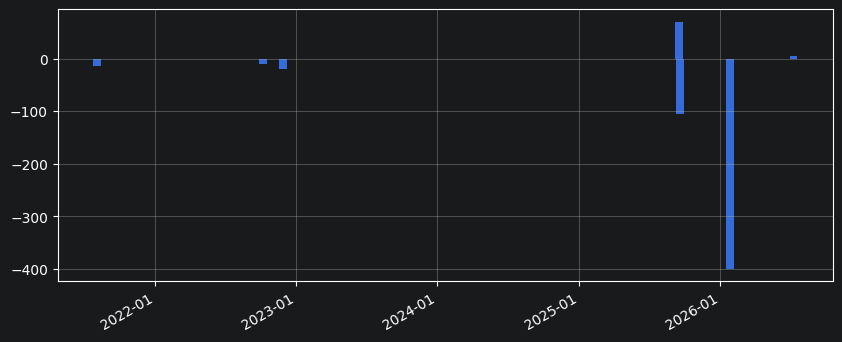

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [13]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,710.00,710.00,577.00,710.00,707.00
mean,0.01,0.02,4132.50,0.14,-0.01
std,37.27,37.27,16091.33,0.33,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,57.94,0.01,0.00
50%,-10.00,-10.00,133.40,0.04,0.00
75%,-1.00,-1.00,305.00,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [14]:
data.nunique().sort_values(ascending=False)

asset_price     568
asset_amount    564
date            563
notes           405
asset_type      168
amount           60
net_amount       59
trans_type       10
trans_id          8
fee               6
name_trans        6
account           5
status            3
currency          1
dtype: int64

In [15]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    497
Deposits                      67
Stock Sell                    47
Stock Dividends               43
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   9
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,497,10.37,1.00,10.00,10.00,10.00,50.00
Deposits,67,88.60,1.00,50.00,100.00,100.00,200.00
Stock Sell,47,10.94,3.00,8.85,10.00,10.16,20.89
Stock Dividends,43,0.09,0.01,0.04,0.07,0.14,0.30
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,9,12.22,5.00,10.00,10.00,20.00,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      33
XYZ      14
ORCL     13
AMZN     12
WFC      12
META     12
JPM      12
V        10
MCD      10
PZZA     10
VONV      9
DELL      9
NFLX      8
DOW       8
MSFT      8
GOOG      8
GOOGL     8
UBER      8
VOO       7
VMBS      7
FISV      7
HOOD      7
DAL       6
WMT       6
AAPL      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

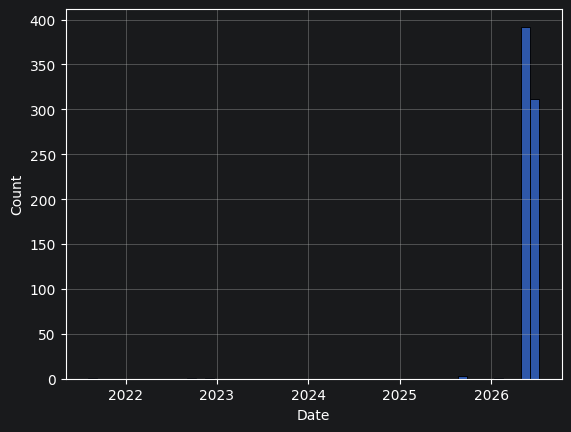

In [18]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [19]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-09,2026-05-27,2026-05-30,2026-06-03,2026-06-03,2026-06-18,2026-07-01,2026-07-06,2026-07-10


In [20]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,33,-136.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,14,-181.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,13,-110.00,"(-10.0, -5.0)",2
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
V,10,-81.00,"(-25.0, -20.0, -10.0, -5.0, -1.0, 20.0)",6


In [21]:
data['currency'].value_counts()

currency
USD    710
Name: count, dtype: int64

In [22]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    497
Deposits                      67
Stock Sell                    47
Stock Dividends               43
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                   9
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [23]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,9,497,43,47,620
BTC,24,9,0,0,0,33
XYZ,0,0,13,0,1,14
ORCL,0,0,13,0,0,13
AMZN,0,0,12,0,0,12
JPM,0,0,10,0,2,12
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
MCD,0,0,9,1,0,10


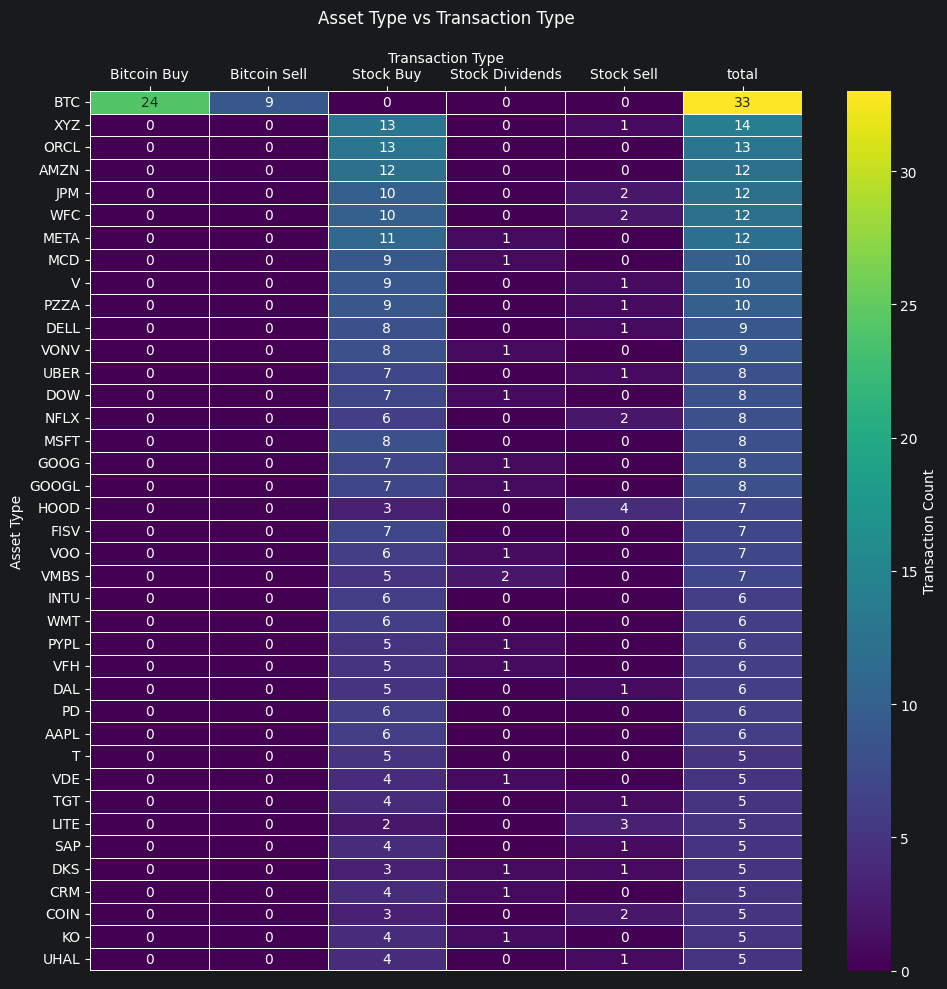

In [24]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [25]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
1,2026-07-11 11:26:39+00:00,9.8,10.0,63645.54,0.000157,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
12,2026-07-10 14:02:46+00:00,9.8,10.0,63970.87,0.000156,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
33,2026-07-06 16:44:23+00:00,9.8,10.0,63170.74,0.000158,-0.2,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
45,2026-07-02 17:10:19+00:00,19.6,20.0,61217.07,0.000327,-0.4,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN
73,2026-07-01 14:21:49+00:00,-10.0,-9.8,60409.85,0.000162,-0.2,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00016223,NaN


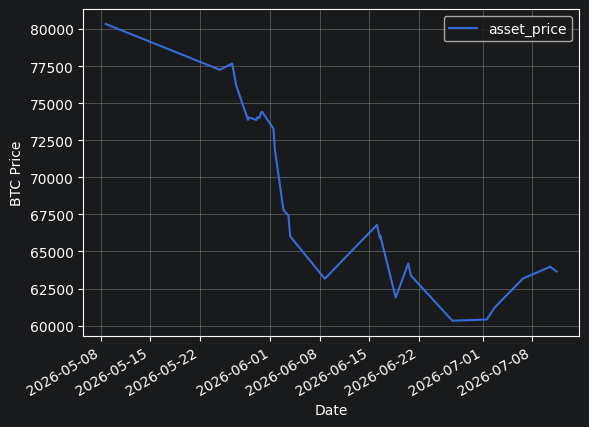

In [26]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [27]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell     9
Name: count, dtype: int64

In [28]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.0
Bitcoin Sell,107.8


In [29]:
data_btc['net_amount'].sum()

np.float64(-144.2)

In [30]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001748
Name: asset_amount, dtype: float64

In [31]:
data_btc['asset_amount'].sum()

np.float64(0.005167250000000001)

In [32]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00167199)

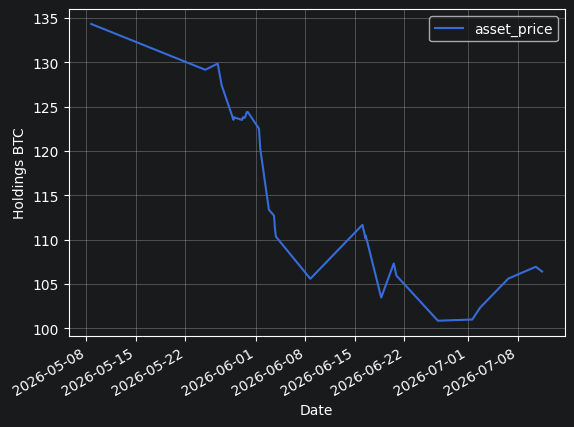

In [33]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [34]:
data_btc['asset_price'] * data_btc['asset_amount']

1       9.999987
12      9.999926
33      9.999928
45     20.000229
73      9.800290
110     4.900090
165    10.000046
167     4.899747
176    19.999846
258     5.000156
259     4.999899
262     4.900240
298    19.999798
378     9.799846
405     9.800287
429     0.980144
526     9.800221
537     0.979969
554     9.799652
612     4.900136
614     9.799865
617     4.900112
618     9.799903
622     9.799965
626    24.500200
633    24.499951
637    24.500084
656     9.799731
660     9.800031
683    24.499991
700     9.799898
701     4.900356
702     9.799819
dtype: float64

In [35]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
28,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
109,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
138,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
220,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
265,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
313,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
389,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
401,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
414,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
452,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


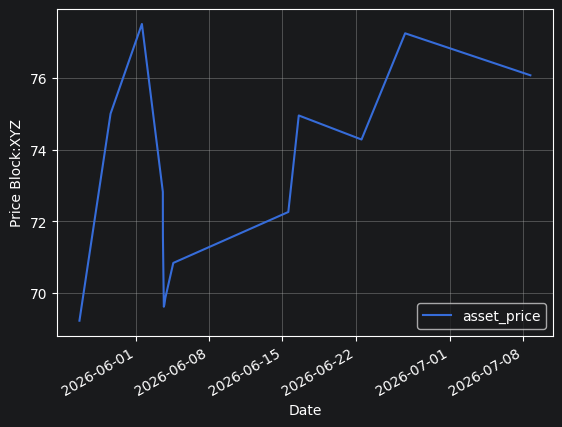

In [36]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [37]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     33
XYZ     14
ORCL    13
META    12
WFC     12
        ..
MU       1
UNFI     1
MSGS     1
RIVN     1
ZG       1
Name: amount, Length: 168, dtype: int64

In [38]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [39]:
data['asset_amount'].describe()

count    710.000000
mean       0.139553
std        0.326795
min        0.000000
25%        0.007935
50%        0.044605
75%        0.127315
max        4.509170
Name: asset_amount, dtype: float64

In [40]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 15:10:08+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000,41.665912,9.686363,19.992722,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-03 15:18:18+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000,41.665912,9.686363,27.762524,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-03 19:38:07+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-03 19:46:16+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-16 13:32:28+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,82.321949,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-16 15:47:18+00:00,28.691891,9.999493,11.181242,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,81.303113,18.724670,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-22 13:30:48+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-06-22 13:31:02+00:00,37.937295,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,42.997334,19.954137,9.999727,9.999925
2026-07-02 13:30:14+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.862441,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925


In [41]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(4035.6409414)

In [42]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    213.016455
XYZ     188.313567
DELL    117.932301
MCD      98.010046
UBER     96.165081
Name: 2026-07-11 14:29:05+00:00, dtype: float64

In [43]:
asset_holding_time_last.tail()

asset_type
ILMN    0.0
VDC     0.0
HPQ     0.0
VBR     0.0
BTC     NaN
Name: 2026-07-11 14:29:05+00:00, dtype: float64

In [44]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AVGO', 'BBEU', 'BIV', 'BNDX', 'CRM', 'CXSE', 'DKS',
       'EMB', 'FIS', 'GM', 'GSLC', 'HPQ', 'ILMN', 'JEPI', 'KO', 'KWEB', 'MRK',
       'NOBL', 'NVDA', 'OWL', 'PSKY', 'QCOM', 'RUM', 'RUN', 'TSM', 'VBR',
       'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ', 'VONG', 'VSS', 'VTEB', 'XLB'],
      dtype='str', name='asset_type')

In [45]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
102,ADP,$0.15 Dividend from Automatic Data Processing
564,ADP,$10 Purchase of Automatic Data Processing
175,ADP,$10 Purchase of Automatic Data Processing
439,ADP,$10 Purchase of Automatic Data Processing
609,ALKT,$10 Purchase of Alkami Technology
...,...,...
197,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
601,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
42,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
523,XLB,$10 Purchase of Materials Select Sector SPDR


In [46]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-10 21:10:53+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 04:06:40+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 04:08:17+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 04:09:04+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 14:29:05+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478


In [47]:
asset_price_rel.iloc[-1].describe()

count    167.000000
mean       0.005988
std        0.007607
min        0.000000
25%        0.002177
50%        0.003837
75%        0.007336
max        0.052784
Name: 2026-07-11 14:29:05+00:00, dtype: float64

In [48]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.052784
XYZ     0.046663
DELL    0.029223
MCD     0.024286
UBER    0.023829
Name: 2026-07-11 14:29:05+00:00, dtype: float64

In [49]:
asset_price_rel_last.tail()

asset_type
ILMN    0.0
VDC     0.0
HPQ     0.0
VBR     0.0
BTC     NaN
Name: 2026-07-11 14:29:05+00:00, dtype: float64

<Axes: ylabel='Frequency'>

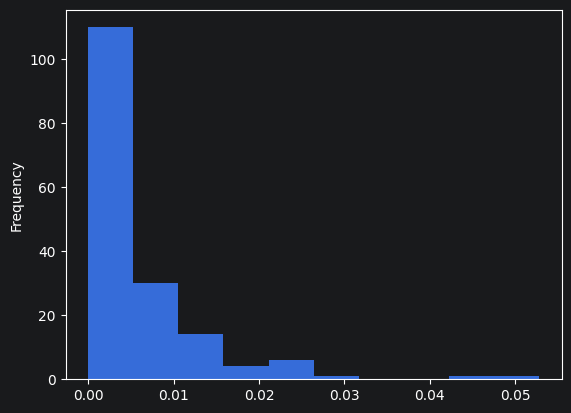

In [50]:
asset_price_rel_last.plot.hist()

In [51]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-10 21:10:53+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 04:06:40+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 04:08:17+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 04:09:04+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478
2026-07-11 14:29:05+00:00,0.015192,0.002478,0.004009,0.004554,0.0,0.002478,0.0,0.005216,0.002241,0.007451,...,0.0017,0.01566,0.005879,0.014646,0.0,0.046663,0.013132,0.004944,0.002478,0.002478


In [52]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:12+00:00,NaN,NaN,NaN,270.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 14:20:16+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:30:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:28+00:00,NaN,NaN,NaN,NaN,223.99,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 13:42:13+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-20 20:54:15+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:01+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.0
2026-06-01 13:30:12+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0
2026-07-01 14:20:16+00:00,0.950374,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-07-10 13:30:21+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-07-01 13:30:01+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-16 13:30:02+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-01 13:30:28+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0
2026-07-01 13:42:13+00:00,0.950374,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-20 20:54:15+00:00,1.018386,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,0.995338,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

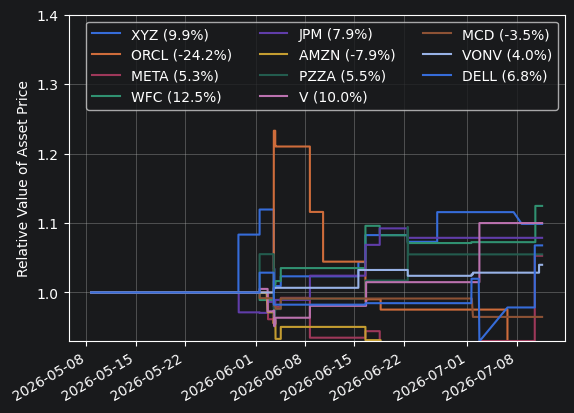

In [54]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [55]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-11 04:06:40+00:00    1.098801
2026-07-11 04:08:17+00:00    1.098801
2026-07-11 04:09:04+00:00    1.098801
2026-07-11 11:26:39+00:00    1.098801
2026-07-11 14:29:05+00:00    1.098801
Name: XYZ, Length: 454, dtype: float64

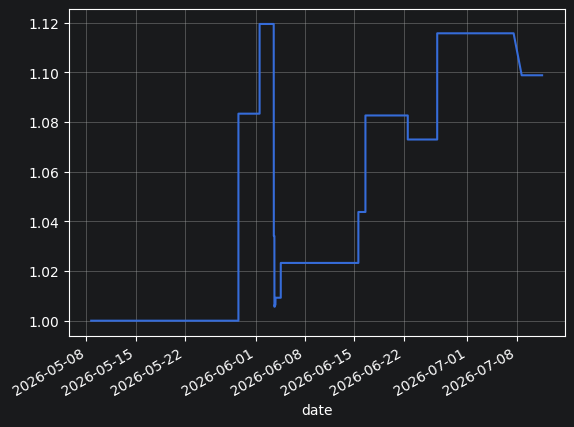

In [56]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [57]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
25,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...
29,2026-07-08,0.07,MRK,$0.07 Dividend from Merck
39,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
40,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
41,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...
42,2026-07-06,0.04,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
43,2026-07-06,0.06,VGLT,$0.06 Dividend from Vanguard Long-Treasury ETF
44,2026-07-06,0.11,VMBS,$0.11 Dividend from Vanguard Mortgage-Backed S...
63,2026-07-02,0.05,CRM,$0.05 Dividend from Salesforce
102,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


In [58]:
div_data['amount'].sum()

np.float64(4.03)

In [59]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
114,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
99,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
121,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
117,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
260,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
111,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
100,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
112,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
131,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
102,2026-07-01,0.15,ADP,$0.15 Dividend from Automatic Data Processing


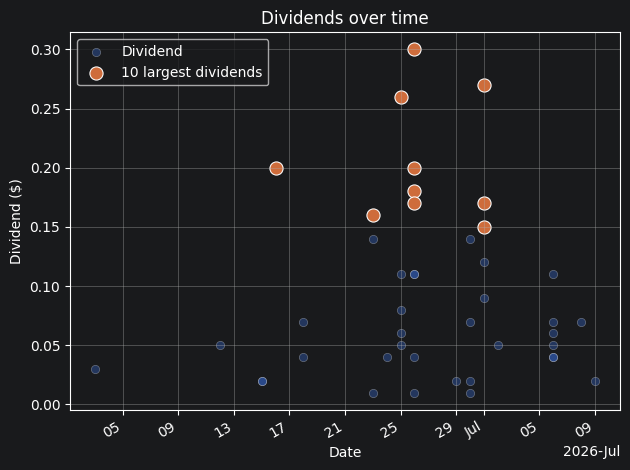

In [60]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [61]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
585,2026-06-01 13:30:16+00:00,-25.00,160.89,$25 Purchase of Energy ETF Vanguard,VDE
129,2026-06-23 04:00:00+00:00,0.01,NaN,$0.01 Dividend from Vanguard Russell 1000 Grow...,VONG
2,2026-07-11 04:09:04+00:00,-10.00,108.27,Scheduled $10 Purchase of Vanguard Russell 100...,VONV
248,2026-06-16 13:30:05+00:00,-5.00,132.21,$5 Purchase of Vanguard Financials ETF,VFH
416,2026-06-03 15:49:05+00:00,-10.00,275.30,$10 Purchase of Vanguard Health Care ETF,VHT
471,2026-06-03 13:30:16+00:00,-10.00,104.82,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
480,2026-06-03 13:30:12+00:00,-1.00,46.56,$1 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
415,2026-06-03 15:49:42+00:00,-10.00,124.12,$10 Purchase of Vanguard Financials ETF,VFH
182,2026-06-18 17:09:02+00:00,-10.00,126.88,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
472,2026-06-03 13:30:16+00:00,-10.00,697.19,$10 Purchase of Vanguard S&P 500 ETF,VOO


In [62]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

In [63]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
585,2026-06-01 13:30:16+00:00,-25.00,160.89,VDE,Energy ETF Vanguard
129,2026-06-23 04:00:00+00:00,0.01,NaN,VONG,NaN
2,2026-07-11 04:09:04+00:00,-10.00,108.27,VONV,Vanguard Russell 1000 Value ETF
248,2026-06-16 13:30:05+00:00,-5.00,132.21,VFH,Vanguard Financials ETF
416,2026-06-03 15:49:05+00:00,-10.00,275.30,VHT,Vanguard Health Care ETF
471,2026-06-03 13:30:16+00:00,-10.00,104.82,VONV,Vanguard Russell 1000 Value ETF
480,2026-06-03 13:30:12+00:00,-1.00,46.56,VMBS,Vanguard Mortgage-Backed Securities ETF
415,2026-06-03 15:49:42+00:00,-10.00,124.12,VFH,Vanguard Financials ETF
182,2026-06-18 17:09:02+00:00,-10.00,126.88,VONG,Vanguard Russell 1000 Growth ETF
472,2026-06-03 13:30:16+00:00,-10.00,697.19,VOO,Vanguard S&P 500 ETF


In [64]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           6
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VDE         Energy ETF Vanguard                            4
VGLT        Vanguard Long-Treasury ETF                     3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VCR         Vanguard Consumer Discretionary ETF            3
VHT         Vanguard Health Care ETF                       3
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
BIV         Vanguard Intermediate Term Bond ETF            2
BNDX        Vanguard Total International Bond ETF          2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VBR         Small Cap Value ETF Vanguard                   2
VTEB        Vanguard Tax-Exem

In [65]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VMBS,VFH,VDE,VGLT,VCR,VNQ,VHT,VSS,BIV,BNDX,VTEB,VBR,VDC,VONG,BSV
date,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VDE     5
VGLT    4
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BSV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

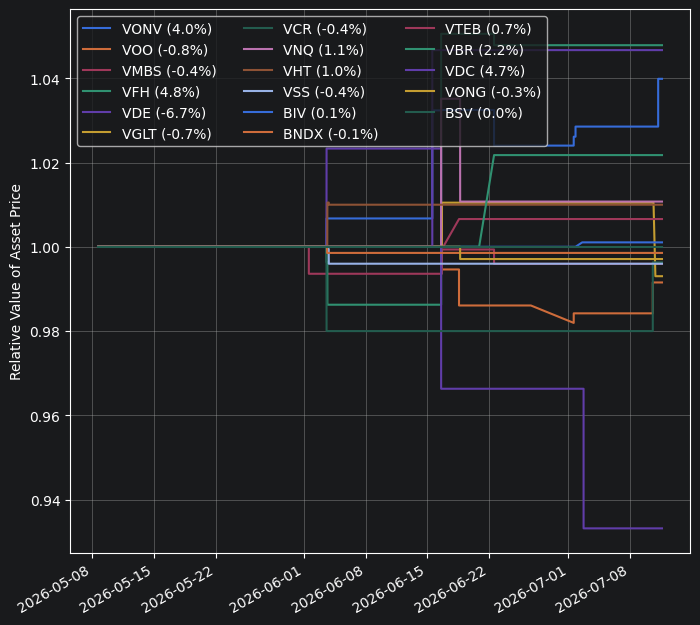

In [67]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [68]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
5,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
23,2026-07-10 13:17:39+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
64,2026-07-01 20:14:16+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
89,2026-07-01 13:41:36+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
164,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
694,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
695,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
696,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
697,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [69]:
data_deposits['net_amount'].sum()

np.float64(5935.96)

In [70]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,67.0,88.596418,49.239706,1.0,50.0,100.0,100.0,200.0


In [71]:
data_deposits['net_amount'].cumsum()

5       100.00
23      200.00
64      300.00
89      400.00
164     500.00
        ...   
694    5830.96
695    5840.96
696    5890.96
697    5910.96
698    5935.96
Name: net_amount, Length: 67, dtype: float64

In [72]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
698,2026-05-26 19:39:34+00:00,25.00
697,2026-05-26 21:58:29+00:00,45.00
696,2026-05-27 00:43:01+00:00,95.00
695,2026-05-27 00:56:05+00:00,105.00
694,2026-05-27 00:56:27+00:00,205.00
...,...,...
164,2026-06-21 21:31:19+00:00,5535.96
89,2026-07-01 13:41:36+00:00,5635.96
64,2026-07-01 20:14:16+00:00,5735.96
23,2026-07-10 13:17:39+00:00,5835.96


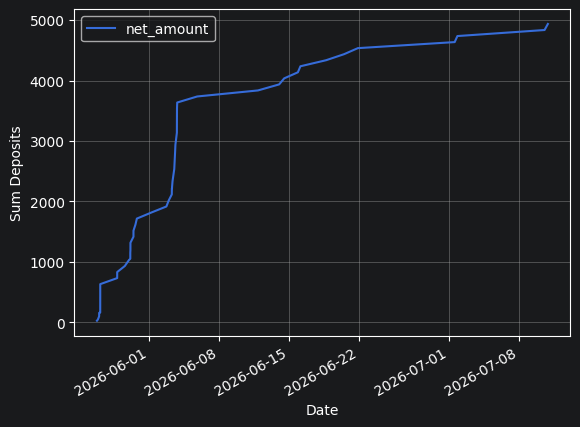

In [73]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [74]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [75]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4600.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64